In [9]:
# 1: Import Libraries and Euler Solver
import numpy as np 
import matplotlib.pyplot as plt 

steps = 1000
nsteps = 1000

def euler_newton(force, times, x0, v0, m,dt):
    # Create arrays for x and v 
    x = []
    v = []

    # Store the initial conditions for the first elements 
    x.append(x0)
    v.append(v0)

    # For loop
    for i in range(steps - 1):

        a = force(times[i], x[i], v[i]) / m
        v.append(v[i] + a*dt)
        x.append(x[i] + v[i+1]*dt)

    return x, v
    
stop=10
times,dt = np.linspace(0, stop, nsteps,retstep=True)

In [6]:
# 2: Terminal Velocity 

# Terminal Velocity for Linear Drag 
def lin_term(t, x, v, b, m):
    term_v = (m*9.8)/b
    return term_v

def quad_term(t, x, v, c, m):
    term_v = np.sqrt((m*9.8)/c)
    return term_v

    

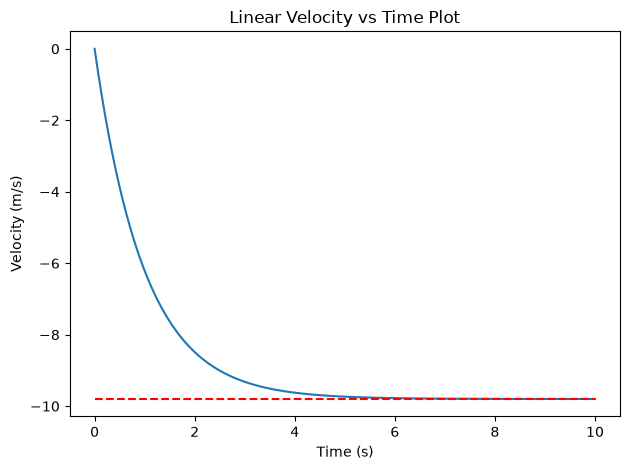

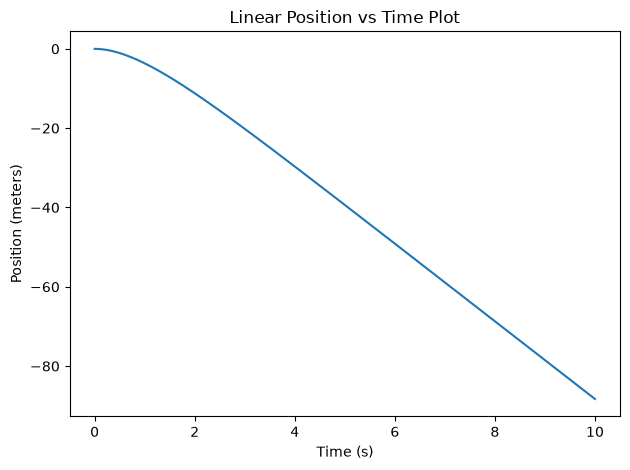

In [25]:
# 3: Linear Air Resistance (Assume b = c = 100 kg/s, the mass of our object is 10g)

# Declare Constants (Begin at Rest)
b = 10
c = 10
m = 10
x0 = 0
v0 = 0

# Linear Drag Force
def lin_drag(t, x, v):
    return -m*9.8 - b*v

# Call to Euler
euler = euler_newton(lin_drag, times, x0, v0, m, dt)

# Plot Velocity vs Time 
plt.plot(times, euler[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Linear Velocity vs Time Plot")
plt.tight_layout()

# Plot Line Representing Linear Terminal Velocity 
x = [0,10]
y = [(-1)*lin_term(times, x0, v0, b, m), (-1)*lin_term(times, x0, v0, b, m)]
plt.plot(x, y, linestyle="--", color="red")
plt.show()

# Plot Position vs Time
plt.plot(times, euler[0])
plt.xlabel("Time (s)")
plt.ylabel("Position (meters)")
plt.title("Linear Position vs Time Plot")
plt.tight_layout()
plt.show() 

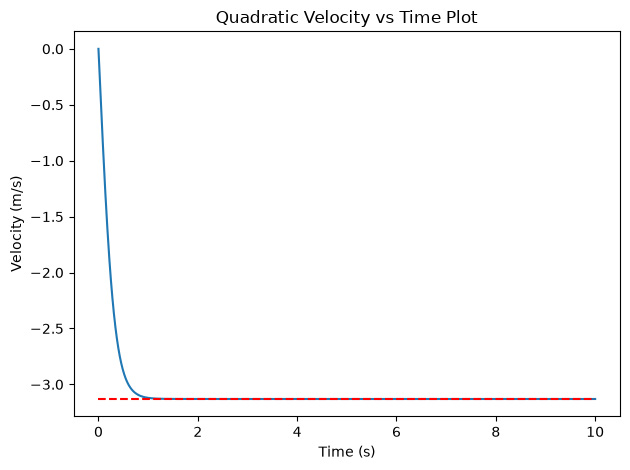

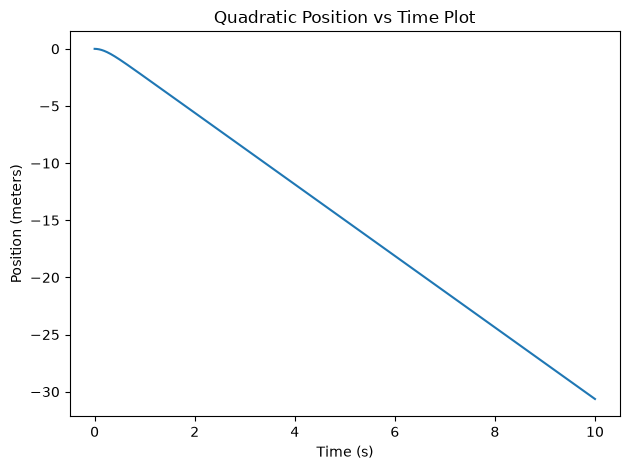

In [27]:
# 4: Quadratic Air Resistance (Assume same ICs from the Linear Air Resistance)

# Declare Constants (Begin at Rest)
b = 10
c = 10
m = 10
x0 = 0
v0 = 0

# Quadratic Drag Force 
def quad_drag(t, x, v):
    return -m*9.8 - (c*v*abs(v))

# Call to Euler
euler = euler_newton(quad_drag, times, x0, v0, m, dt)

# Plot Velocity vs Time
plt.plot(times, euler[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Quadratic Velocity vs Time Plot")
plt.tight_layout()

# Plot Line Showing Quadratic Terminal Velocity
x = [0,10]
y = [(-1)*quad_term(times, x0, v0, b, m), (-1)*quad_term(times, x0, v0, b, m)]
plt.plot(x, y, linestyle="--", color="red")
plt.show()

# Plot Position vs Time
plt.plot(times, euler[0])
plt.xlabel("Time (s)")
plt.ylabel("Position (meters)")
plt.title("Quadratic Position vs Time Plot")
plt.tight_layout()
plt.show()

In [30]:
# Final: Comparisons and Conclusions

# What I've noticed in regards to the Position vs Time graphs is that both
# Linear and Quadratic models output the exact same result.

# What I've noticed in regards to the Velocity vs Time graphs is that the 
# Quadratic model has a steeper slope than that of the Linear model

# However both Linear and Quadratic models have a exponential decay as they 
# approach their respective terminal velocities.